# 📊 Análise de Performance Comercial com Python
Explorando padrões de vendas, faturamento e participação de produtos utilizando Pandas e Matplotlib.

## 🎯 Objetivo
Este projeto tem como objetivo analisar dados de vendas para identificar padrões de faturamento e desempenho comercial.

Serão analisados:

- Faturamento total
- Ticket médio
- Participação de receita por produto
- Evolução mensal de faturamento

A análise busca demonstrar como técnicas de análise de dados podem apoiar decisões estratégicas em negócios.

## 🧮 Contexto de Negócio

Empresas utilizam análise de dados para compreender melhor o comportamento das vendas e orientar decisões estratégicas.

Neste projeto foi utilizada uma base simulada contendo informações de vendas, incluindo:

- Data da venda
- Produto
- Categoria
- Quantidade vendida
- Preço unitário

A partir desses dados foi realizada uma análise exploratória

## 🛠 Tecnologias Utilizadas
- Python
- Pandas
- Matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Criação de dados

np.random.seed(42)

datas = pd.date_range(start="2024-01-01", periods=200)

produtos = ["Notebook", "Smartphone", "Tablet", "Monitor", "Teclado"]

df = pd.DataFrame({
    "data": np.random.choice(datas, 200),
    "produto": np.random.choice(produtos, 200),
    "quantidade": np.random.randint(1,5,200),
    "preco_unitario": np.random.randint(100,3000,200)
})

df.head()

,data,produto,quantidade,preco_unitario
0,2024-04-12,Notebook,3,2003
1,2024-06-28,Monitor,4,828
2,2024-04-02,Notebook,4,1465
3,2024-01-15,Notebook,4,496
4,2024-04-16,Smartphone,1,798


In [4]:
# Criar faturamento

df["faturamento"] = df["quantidade"] * df["preco_unitario"]

## 📈 Indicadores Principais (KPIs)

A seguir são apresentados os principais indicadores de desempenho extraídos da base de dados.

In [5]:
# KPIs

faturamento_total = df["faturamento"].sum()

ticket_medio = df["faturamento"].mean()

print("Faturamento Total:", faturamento_total)
print("Ticket Médio:", ticket_medio)

Faturamento Total: 717186
Ticket Médio: 3585.93


In [6]:
# Faturamento por produto
faturamento_produto = df.groupby("produto")["faturamento"].sum().sort_values()

faturamento_produto

,faturamento
produto,
Teclado,107335
Monitor,121691
Smartphone,135462
Tablet,156758
Notebook,195940


In [7]:
faturamento_produto_formatado = faturamento_produto.apply(
    lambda x: f"R$ {int(x):,}".replace(",", ".")
)

faturamento_produto_formatado

,faturamento
produto,
Teclado,R$ 107.335
Monitor,R$ 121.691
Smartphone,R$ 135.462
Tablet,R$ 156.758
Notebook,R$ 195.940


In [19]:
# Participação percentual de faturamento por produto

participacao = faturamento_produto / faturamento_produto.sum() * 100

participacao

,faturamento
produto,
Teclado,14.966132
Monitor,16.967844
Smartphone,18.887987
Tablet,21.857370
Notebook,27.320667


In [20]:
participacao_formatada = participacao.apply(
    lambda x: f"{x:.2f}%"
)

participacao_formatada

,faturamento
produto,
Teclado,14.97%
Monitor,16.97%
Smartphone,18.89%
Tablet,21.86%
Notebook,27.32%


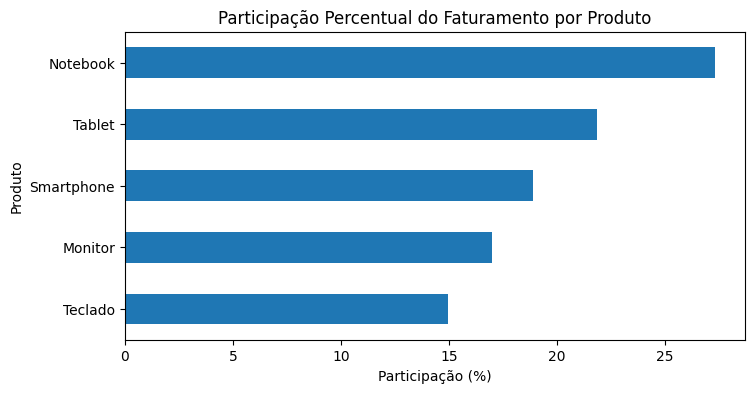

In [9]:
# Gráfico de participação percentual

plt.figure(figsize=(8,4))

participacao_produto.sort_values().plot(kind="barh")

plt.title("Participação Percentual do Faturamento por Produto")
plt.xlabel("Participação (%)")
plt.ylabel("Produto")

plt.show()

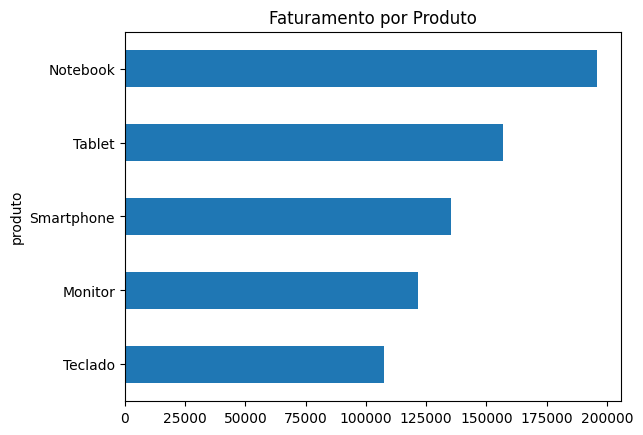

In [10]:
# Gráfico de faturamento por produto

plt.figure()

faturamento_produto.plot(kind="barh")

plt.title("Faturamento por Produto")

plt.show()

In [11]:
# Evolução mensal

df["mes"] = df["data"].dt.to_period("M")

faturamento_mensal = df.groupby("mes")["faturamento"].sum()

faturamento_mensal

,faturamento
mes,
2024-01,106313
2024-02,83494
2024-03,125940
2024-04,122626
2024-05,126396
2024-06,74714
2024-07,77703


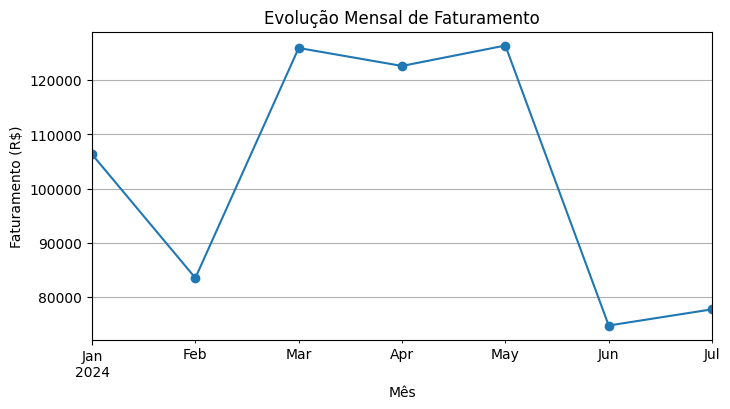

In [12]:
# Gráfico de evolução mensal

plt.figure(figsize=(8,4))

faturamento_mensal.plot(kind="line", marker="o")

plt.title("Evolução Mensal de Faturamento")
plt.xlabel("Mês")
plt.ylabel("Faturamento (R$)")

plt.grid()

plt.show()

## 💡 Insights da Análise

A análise do faturamento por produto demonstra que o **Notebook** apresenta a maior participação no faturamento total, representando aproximadamente **27% da receita**. Em seguida aparecem **Tablet (21%)** e **Smartphone (18%)**, indicando que esses produtos possuem maior relevância financeira no conjunto de vendas analisado.


 Os produtos **Monitor (16%)** e **Teclado (14%)** apresentam menor participação no faturamento total, sugerindo um baixo impacto financeiro quando comparados aos demais itens do portfólio.

 Na análise da evolução mensal de faturamento, observa-se uma **queda nas vendas em fevereiro**, seguida de uma recuperação significativa em **março e abril**. O maior volume de faturamento ocorre em **maio (R$ 126.396)**, indicando um possível pico de demanda no período analisado.

Por outro lado, **junho apresenta o menor faturamento do período**, com **R$ 74.714**, seguido por uma leve recuperação em julho.

De forma geral, a análise demonstra como técnicas de exploração e visualização de dados podem ser utilizadas para identificar padrões de vendas, avaliar a performance de produtos e apoiar a tomada de decisão em ambientes comerciais.